In [1]:

# ============================================================
# Course setup: Run this cell to copy all the necessecary files from the github to your local drive area.
# Only run if using online colab; if using a local copy e.g. through jupyter notebook, this cell is unnecessecary
# ============================================================

import os
import sys

REPO_URL = "https://github.com/IanEstabrook/CMCB_Practical_Course_Vertex_Modelling.git"
REPO_DIR = "/content/CMCB_Practical_Course_Vertex_Modelling"

# Clone repository if it is not already present
if not os.path.exists(REPO_DIR):
    !git clone -q {REPO_URL} {REPO_DIR}

# Make the course package available to Python
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

print(f"Course repository: {REPO_DIR}")


fatal: could not create leading directories of '/content/CMCB_Practical_Course_Vertex_Modelling': Permission denied
Course repository: /content/CMCB_Practical_Course_Vertex_Modelling


In [2]:
from IPython.display import display, HTML

display(HTML("""<style>.jp-RenderedHTMLCommon,.jp-RenderedHTMLCommon p,.jp-RenderedHTMLCommon li {    font-size: 40px !important;}
.rendered_html,.rendered_html p,.rendered_html li {    font-size: 20px !important;}</style>"""))

# Welcome to the CMCB: Vertex models of collective cell dynamics course 2026.

This Notebook will guide you through creating a vertex based model, which is one method used to understand behaviour of confluent meshes of cells, which joined together form a tissue.

During embryogenesis, cells demonstrate complex self organised patterns driven by cell-cell interactions. In this practical, we will explore how to construct vertex models, which contain information about how cell shape, adhesion and cortical tensions can be incorporated to mathematical models, and how these microscopic interactions can influence tissue-scale self organisation. 




# A brief introduction:


Hello! Welcome to the CMCB course practical from the Erzberger lab on Vertex models of collective cell dynamics. 

In this practical we will introduce you to vertex model based methods, used in modern theoretical biophysics to model multicellular dynamics. We will focus on how multicellular scale behaviour emerges in a system which can be modelled from cell level properties, using a elastic based vertex model of an epithelial sheet of cells as an example.

In the taught sections of this practical, we will describe how we might model a flat 2D surface of cells, and which biophysical considerations have historically gone in to such a model at the cell level. We'll look at how different parameter choices let us replicate tissue scale observed behaviours from lower scale properties of individual cell shapes and interactions. 

The exercises will follow a numerical/computational description of the process, with exercises providing a step by step computational approach of building a energetic vertex based model. Energetic based descriptions occur throughout (bio)physics, and can be used for a wide variety of tissue behaviours beyond this course. By varying different cell parameters, you will be able produce examples of how cell scale properties and interactions result in different regions of tissue scale behaviour, primarily the solid and fluid like states of confluent tissues. 


## Aims for the practical:

*   To understand (some of!) the approaches used in biophysical modelling
*   To apply these approaches to an epithelial layer through a "vertex model"
*   To demonstrate how cell level properties can lead to different behaviours on the tissue scale


# What Are Vertex Models, and how can they help us understand biological systems?

Vertex models are a class of models which represent a confluent layer(s) of cells as interacting polygons. They were originally inspired by other non-biological classes of soft matter -particularly soap bubbles [\[1\]](#cite-note-1) and foams [\[2\]](#cite-note-2). In these, and other fluid-like systems, shape and pattern evolutions over time are driven by competition between internal pressure and surface tension, which can result in a wide range of observed behaviours, depending on the relative strengths of these terms.

## Vertex models and Epithelial confluent surfaces
For this short course, we primarily consider how vertex models can be applied to epithelial layers.

Epithelial layers can be visualised through light microscopy images with stains which display the cell membranes, e.g. 
![ExampleOfAnEpithelialDrosophilaEmbryo](Figures/Experimental_Images/Epithelial_Drosophila_Example_2.png)
Image provided courtesy of Anne Rosfelter; Yu-Chiun Wang, RIKEN Center for Biosystems Dynamics Research (BDR).

In a vertex model, the embryo surface can be treated as a confluent mesh whose dynamics are captured by the behaviours of the mesh which represents the cell shapes. For this image, a mesh based representation of the current state using a skeletonisation algorithm could look like:

![ExampleOfAnEpithelialDrosophilaMesh](Figures/Experimental_Images/Epithelial_Drosophila_Example_3_meshVers.png)

A fundamental assumption in vertex modelling is that a significant amount of multicellular behaviours can be captured by only directly modelling the positions of the vertices, shown as red dots here, rather than the entire cell body:
![ExampleOfAnEpithelialDrosophilaMeshWithV](Figures/Experimental_Images/Epithelial_Drosophila_Example_mesh_with_vertices.png)

/home/estabroo/Dropbox/academic_work/Epithelial_nuclei_EMBL_Heidelberg/Conference_Presentations/20260915_Current_Methods_In_Cell_Biology
/home/estabroo/Dropbox/academic_work/Epithelial_nuclei_EMBL_Heidelberg/Conference_Presentations/20260915_Current_Methods_In_Cell_Biology/Figures/Experimental_Images/Epithelial_Drosophila_Example_3_meshVers.png
True


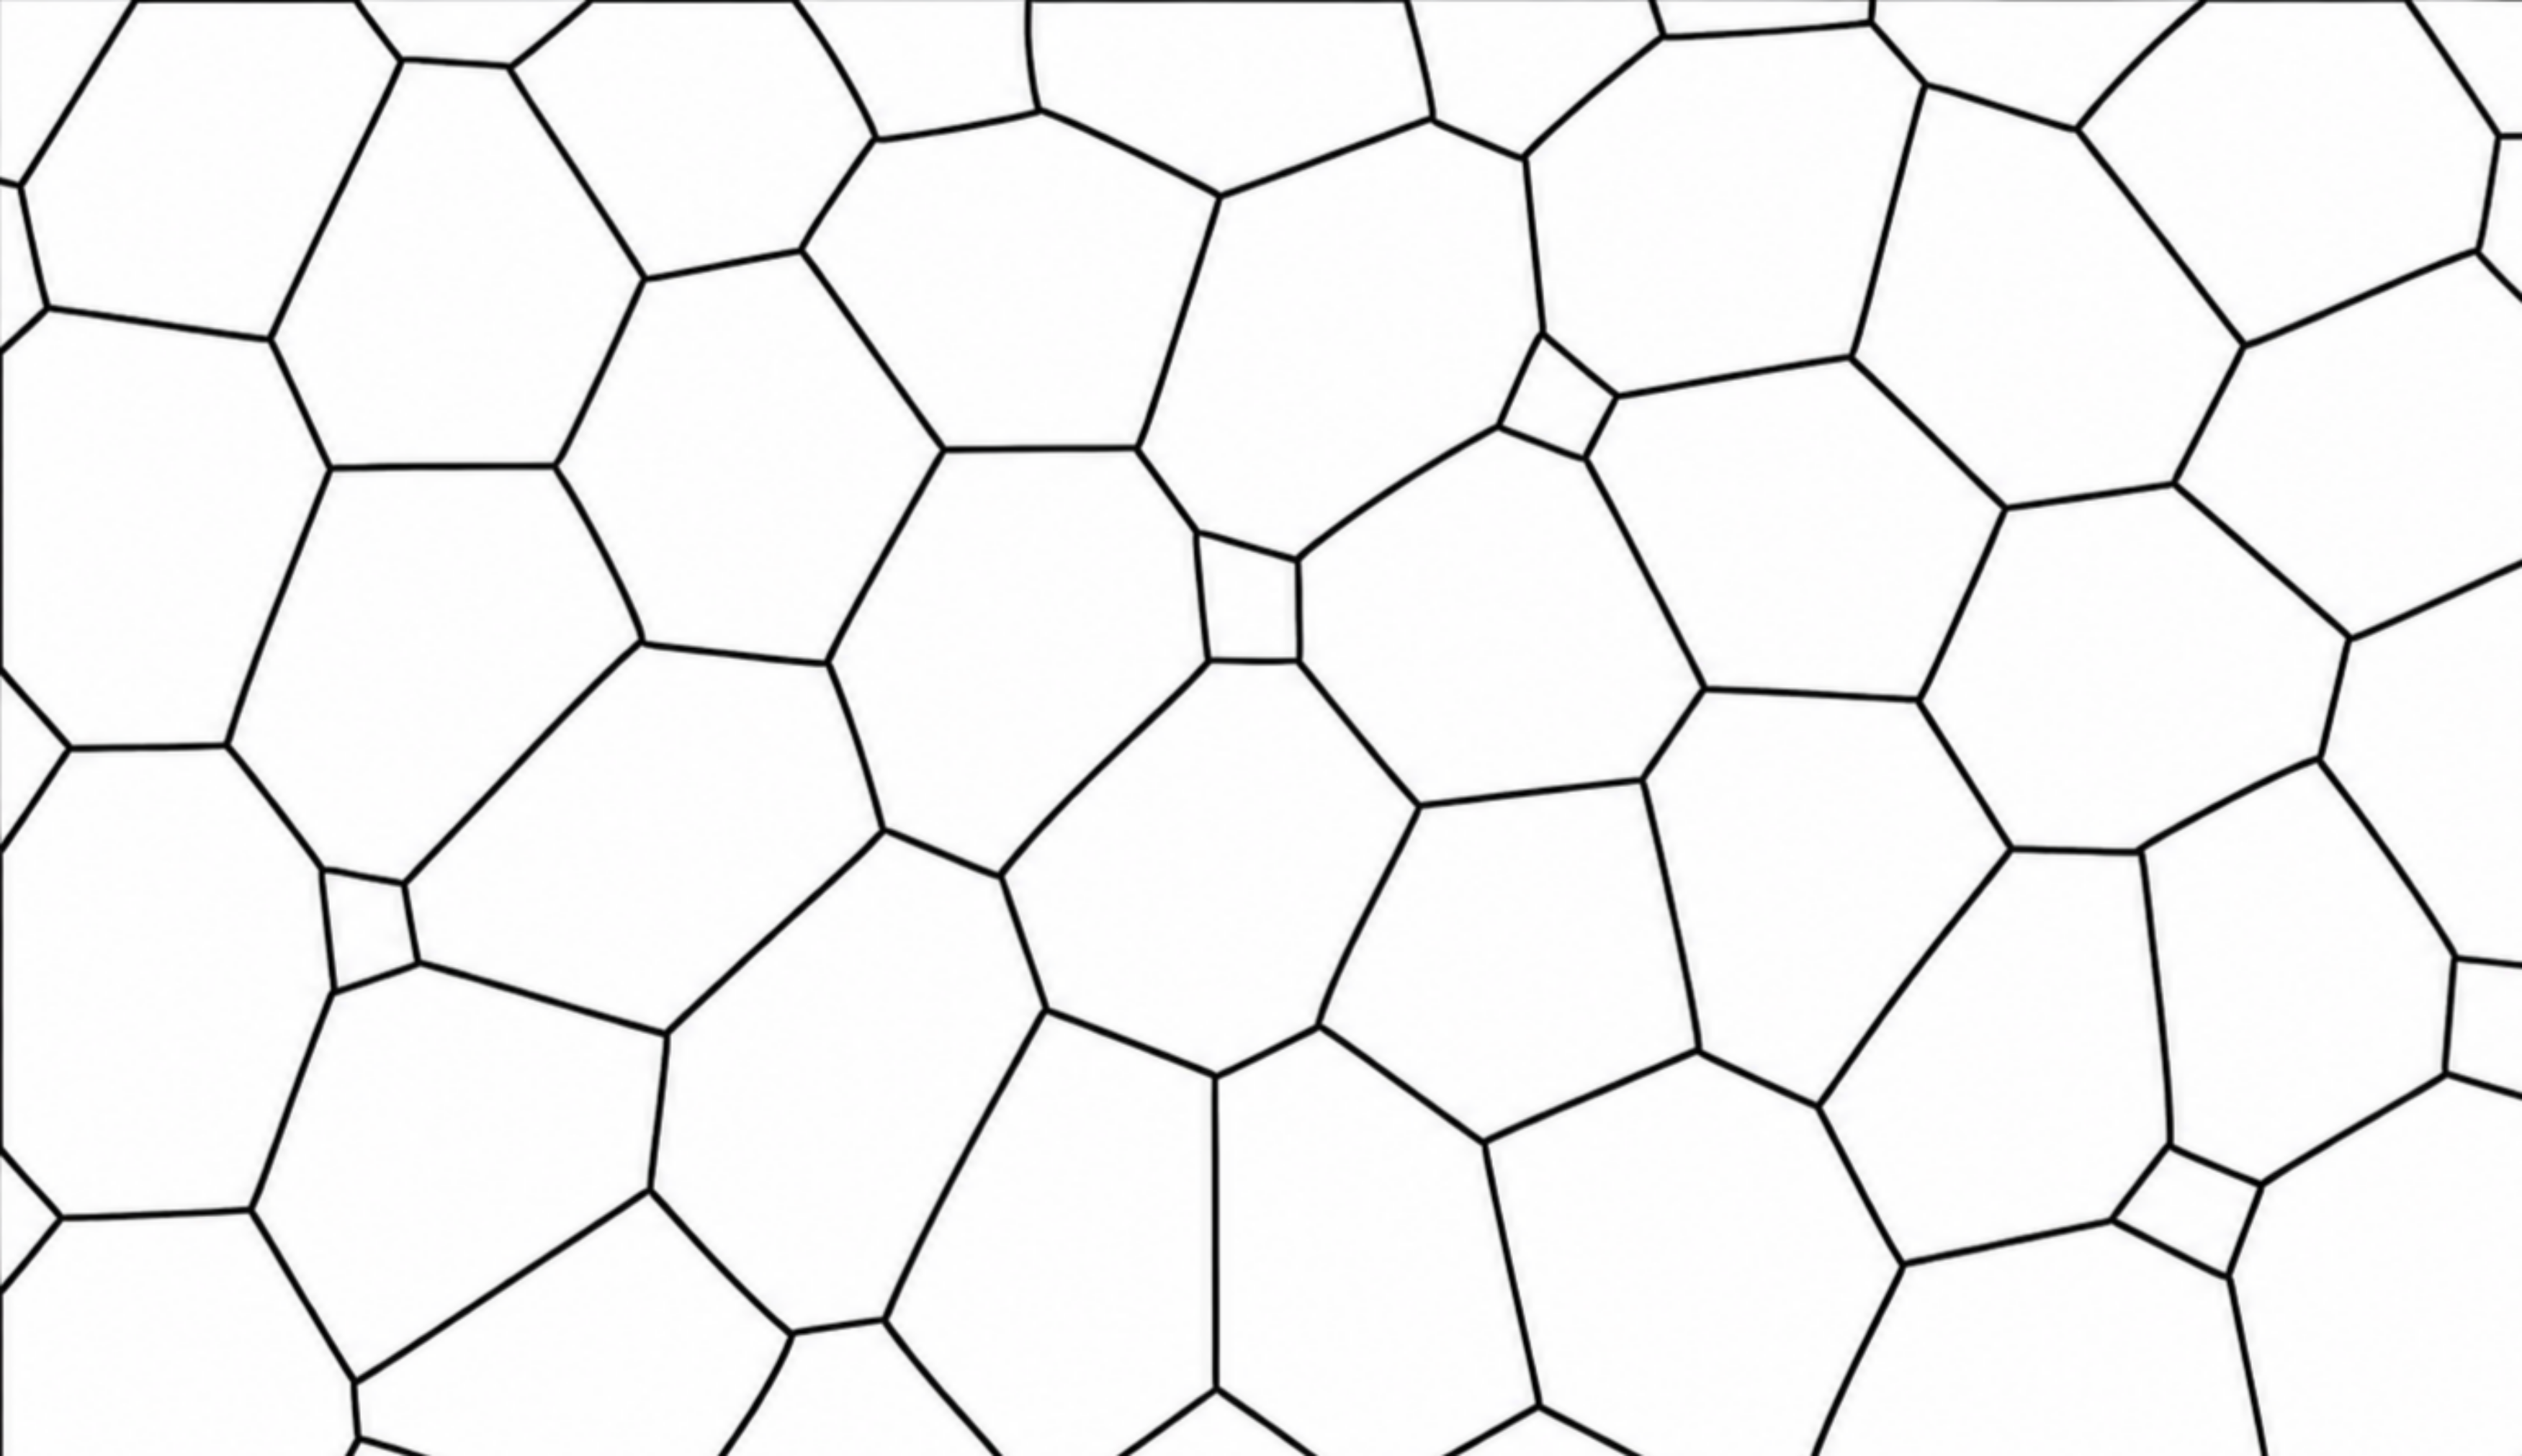

In [3]:
from pathlib import Path

p = Path("Figures/Experimental_Images/Epithelial_Drosophila_Example_3_meshVers.png")
print(Path.cwd())
print(p.resolve())
print(p.exists())
from IPython.display import Image, display

display(Image(
    filename="Figures/Experimental_Images/Epithelial_Drosophila_Example_3_meshVers.png"
))

# Setting up the geometry of an epithelial layer in a vertex model

# Exercise 1: Let's create a epithelial hexagon mesh!

For this course, classes, functions and methods are provided in other .py files to create your simulations. You may want to add or modify your own methods as we go.

As we saw above, in an image of a epithelial monolayer, we can identify cells their boundaries (edges), neighbours and positions just from the positions of vertices which when joined by straight edges, form polygonal "cells".

Let's begin with creating a hexagonal mesh. The Tissue we will simulate is defined in the class within source_pyfiles/tissue.py. The helpfully named tissue class within defines the tissue as a list of vertices, and connected edges. We can then generate a mesh of regular hexagons using the functions in source_pyfiles/mesh.py

The mesh depends on the size of the hexagon (a) and the number of hexagons which are tiled along the two directions. Depending on the simulation, we may want the boundaries to be periodic, which is an argument that can be passed to the mesh generation function.

Familiarise yourself with the mesh generation code. What happens if we have an odd number of cells in one direction? Adjust the code in mesh.generate_hexagonal_sheet to enforce that we have an even number of cells if the top/bottom or sides are periodic.

Check using the plotting functions provided in plotting.py that edges are shared and that vertices at the boundaries are tracked appropriately.

The functions here are:
mesh.generate_hexagonal_sheet(tissue,Nx,Ny,a,top_bottom_boundary_periodicity=False,side_boundary_periodicity=False)

with parameters: 

Nx, Ny: The number of hexagons along x and y in the initial mesh

a: a float number which defines the initial sizes of the sides of hte hexagonal mesh.

top_bottom_boundary_periodicity=True,side_boundary_periodicity=True, which defines if there is periodic behaviour along the surface in the defined directions. If both are true, the surface acts as an infinitely sized tissue in both directions.

plotting.plot_mesh(tissue,show_cell_ids=False,show_vertex_ids=False,show_periodic=False,show_edge_ids=False)

Generates a plot of the tissue. Setting the various parameters , show_cell_ids=False,show_vertex_ids=False,show_periodic=False,show_edge_ids=False to True will display the cell id numbers, vertex ids, periodic boundaries, and edge ids respectively.

## Task: Generate some meshes using these functions, and check the various periodicities are correctly functioning.

Generating mesh 1


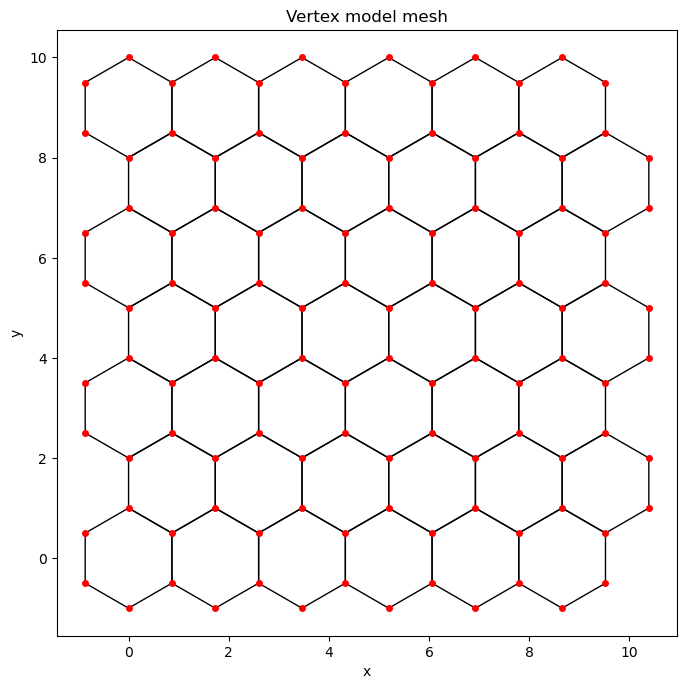

In [4]:
from source_py_files.tissue import Tissue 
from source_py_files import mesh
from source_py_files import plotting


Nx = 6
Ny = 7
a = 1

tissue = Tissue()

print("Generating mesh 1")
mesh.generate_hexagonal_sheet(tissue,Nx,Ny,a,top_bottom_boundary_periodicity=False,side_boundary_periodicity=False)
plotting.plot_mesh(tissue,show_cell_ids=False,show_vertex_ids=False,show_periodic=False,show_edge_ids=False)


# So how do we get from some hexagons, to a physically (or biologically!) meaningful statement on how a system evolves

## Updating a mesh like a physicist: How does a physical system evolve? 

In physics, systems that aren't under external forces, or otherwise actively consuming energy to prevent such changes, will move to minimise the energy of the system. This can be seen in systems all across nature, whether it is a ball in a gravitational field, who will roll down a hill to minimise gravitational potential energy, (increasing kinetic energy as it does, until at the minimum of the local gravitational potential, but lets not worry about that!)
![ExampleOfGravitationalEnergy](Figures/Drawings/example_ball_energy.png)

The change in gravitational potential energy is $U_{gravity} = mg \Delta h$
Another perhaps more relevant example is when an elastic band or spring is stretched (or compressed in the case of a spring), energy is stored within the spring, which then wants to return the spring to the original shape.

![ExampleOfElasticEnergy](Figures/Drawings/elastic-potential-energy.jpg) 
From : https://eschooltoday.com/learn/elastic-potential-energy/

would have energies proportional to how far the spring has stretched or compressed in the form 

\begin{align}
E_{\text{spring}} = \frac{1}{2} k \Delta x^2
\end{align}

Bubbles are capable of forming thin shells of fluid material which have shapes determined by surface tension. In the absence of other bubbles and external forces, this will result in a spherical bubble. If there are interactions between other bubbles, then the energy involves bubble-bubble contact depending on the surface area as

\begin{align}
E_{\text{bubble}} = k_{p_{bb}} \sum_{i<j} l_{ij} + k_{p_{bf}}\sum _{i} l_{i}
\end{align}
where $k_p$ is a strength of surface tension, or adherence between surfaces. In the case of $k_{p_{bb}}$ this represents the adherence based interaction between bubbles i and j, and $k_{p_{bf}}$ represents the effect of surface tension over the area of the cell in contact with the surrounding environment.


# What are the energies involved in a biologically motivated vertex model?  

Our starting mesh now will look something like : 
![10By10MeshPlot](Figures/Mesh_plots/Example_plot_10by10_mesh) 

What measurable geometric properties does each cell have, and how might they contribute to the energies of our system? As mentioned earlier, vertex models were inspired from soap bubbles and foams, we can take inspiration from these, as well as elastic spring like interactions.

We might therefore be tempted to include phenomena like those systems. In terms of an epithelial sheet, the energy can represent various behaviours, all of which are coarse-grained in to different terms. Traditionally, the energies included are:

## An area elasticity term: 
\begin{align}
E_{area}=\frac{1}{2} k_A (A-A_0)^2 
\end{align}

which represents, for instance, how Cytosol resists compression and expansion forces;

## An perimeter elasticity term:

\begin{align} E_{perimeter} = \frac{1}{2} k_p \left(P-P_0\right)^2\end{align} 
 
e.g. The actomyosin ring around the circumference of the cell exerts contractile forces.

## An edge tension term:

\begin{align} E_{edge}=\frac{1}{2} \sum_{edges<ij>} \Lambda_{ij} l_{ij} \end{align}
    
Describes how Adherent cell-cell junctions result in attractive forces along boundaries. 

## The total energy of a vertex
  
    
Is given by the sum of all of these. 
   
\begin{align}
E_{vertex}=E_{area}+ E_{perimeter} +E_{edge}
\end{align}


# Exercise 2: What effect does changing a vertex position have on the energy landscape for different parameters?

Now that we've established the form of energy of a cell, what can we actually learn from describing a cell in terms of the energy?

Let's start by investigating how changing one cell affects the energy of the system for different choices of parameters.

There are a total of 5 different parameters we can vary at the moment in the energy of our cells: The preferred Area $A_0$, the preferred perimeter of a cell $P_0$, the resistance to area changes, $k_a$, the resistance to perimeter changes $k_p$, and the degree of edge tension $\Lambda$. 

## Task:
Use the following code to explore graphically what the energy landscape of moving a single cell a small amount looks like for different parameters. Take particular note for ones where the energy landscape is positive or negative, and what effect, if any, choosing different vertices has on the pattern.

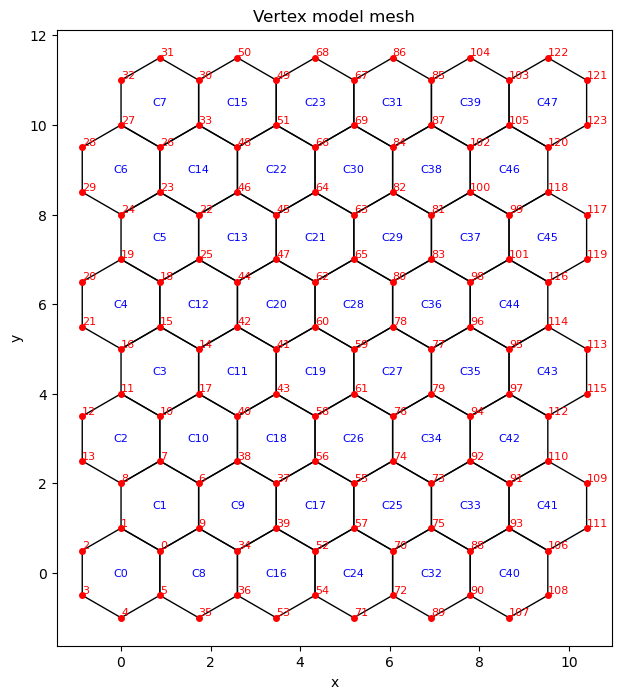

6.000005551444137


KeyboardInterrupt: 

In [5]:
#Show a plot to with tissue vertices,to select an example vertex. 
tissue=Tissue()

mesh.generate_hexagonal_sheet(tissue,Nx,Ny,a,top_bottom_boundary_periodicity=True,side_boundary_periodicity=True)

plotting.plot_mesh(tissue,show_cell_ids=True,show_vertex_ids=True,show_periodic=False,show_edge_ids=False)
#Example of a cell which is at a preferred shape/area
from source_py_files import energy as energy_module
from source_py_files import geometry
import numpy as np

#Choose a vertex
selectedVertexId = 10

#We will make lots of little moves of the selected vertex around the start position;
dx_values = np.linspace(-1.0, 1.0, 101) #From -1.0 to 1.0 in 101 increments
dy_values = np.linspace(-1.0, 1.0, 101)

kaValue=1.0;
kpValue=1.0;
LambdaValue=0.0;
A0Value=2.6
P0Value=8.0

tissue.set_preferred_properties(A0=A0Value,P0=P0Value)
energy_change = np.zeros((len(dy_values), len(dx_values)))
    
# Energy of the original configuration, because the important part is how this changes.
E0 = energy_module.local_cell_energy(tissue,selectedVertexId,ka=kaValue,kp=kpValue,Lambda=LambdaValue)
print(E0)

for i, dy in enumerate(dy_values):
    for j, dx in enumerate(dx_values):
        # Move vertex
        tissue.move_vertex(selectedVertexId,[dx, dy, 0.0])
        E=energy_module.local_cell_energy(tissue, selectedVertexId, ka=kaValue, kp=kpValue, Lambda=LambdaValue)
        # Store energy difference
        energy_change[i, j] = E - E0
        # Restore original position
        tissue.move_vertex(selectedVertexId,[-dx, -dy, 0.0])


plotting.plot_energy_landscape(dx_values,dy_values,energy_change,selectedVertexId)



# Aside: How do we go from an energy to actually updating vertex positions?

## Anyone who doesn't want to read some maths can skip this box!

# Deriving forces acting on cells from energy perturbations.

Given the expression for energy we now have above, containing Area elasticity, Perimeter elasticity and interface tensions,

\begin{align}
E=\frac{1}{2} k_A (A-A_0)^2 + \frac{1}{2} k_p \left(P-P_0\right)^2 + \frac{1}{2} \sum_{<ij>} \Lambda_{ij} l_{ij}
\end{align}
    
We can determine the force acting on a given vertex in the 2D plane of our epithelial layer by looking at how changing the position of the vertex affects the energy. Specifically, in the overdamped limit, the force on a vertex is given by the derivative of the vertex position:
    
\begin{align}
{\bf F_i} = -\frac{\partial E}{\partial {\bf r}_{i}}
\end{align}
    
Where $ {\bf r}_{i}$ is the position of the vertex i.
    
The derivative of the energy can actually be derived analytically here, but we'll avoid doing that and instead talk about what this means numerically.    
    
## A short introduction to partial derivatives
For those who are already confident with these methods, you can skip this section or relax for a few minutes!

Derivatives measure how something changes in space. For instance, if we know the distance above sea level of the bus coming to EMBL depends on how far you are from Alois-Link Platz, we could write this as $z=z(x)$, where x is the distance from the Alois-Link Platz bus stop to the EMBL bus stop. Of course, this goes up and down so the actual curve might look like : 

    (*Make image of a graph for derivative?*)
As you move a little distance $\delta$ along the bus route between Alois-Link Platz and EMBL, your height above sea level, z changes a bit. The derivative measures how much the height changes over the bus route. 
    
For a small enough $\delta$ this is approximately linear and we can write the change in height ratio to delta as:
\begin{align}
\text{relative height change} = \frac{z(x+\delta)-z(x)}{\delta}
\end{align}
    
But what is a good size for $\delta$? If the curve was very wiggly, perhaps our initial choice was too big. In that case we can make $\delta$ smaller. We could also keep doing this and take $\delta$ to be ***infinitesimally small***. This is called taking a limit of $\delta$ tending to zero, and is written like this:
    
\begin{align}
\frac{dz}{dx} = \lim_{\delta->0}\frac{z(x+\delta)-z(x)}{\delta}
\end{align}

This is the definition of an ordinary derivative! ***The ordinary derivative gives the slope of a function at the position $x$***.
    
However, the bus trip is actually a curve with lots of ups and downs and it might make more sense to write the position in the xy coordinates you would see on a map projection e.g.: 

\begin{align}
\text{slope} = \frac{z(x_2,y_2)-z(x_1,y_1)}{\delta}
\end{align}

Mathematically, we often only want to know how the function changes with respect to one variable.  If I only want to measure the change in x (latitude) at different points, I might want to keep y constant, which is where the partial derivative comes in.
    
\begin{align}
\text{slope along x} = \frac{z(x+\delta,y)-z(x,y)}{\delta}
\end{align}
Taking the limit of small movements, as before, ($\delta -> 0$) we get the partial derivative definition
\begin{align}
\frac{\partial z}{\partial x} = \lim_{\delta->0}\frac{z(x+\delta,y)-z(x,y)}{\delta}
\end{align}
This is the definition of a partial derivative! Here we use the symbols $\partial$ to indicate that we keep all other variables fixed when we change $x$.
    
However, when doing numerical calculations, it is often advantageous to use a different form, which is symmetric around the position the measurement is being taken at:

\begin{align}
\frac{\partial z}{\partial x} = \lim_{\delta->0}\frac{z(x+\delta,y)-z(x-\delta,y)}{2\delta}
\end{align}

The reason this form is typically chosen is because this greatly decreases the error in our measurement.

Following the same logic, we can measure the partial derivative in y as 

\begin{align}
\frac{\partial z}{\partial y} = \lim_{\delta->0}\frac{z(x,y+\delta)-z(x,y-\delta)}{2\delta}
\end{align}

# How can we incorporate the forces acting on a vertex and so predict how a cell position, shape changes?

\begin{align}
{\bf F_i} = -\frac{\partial E}{\partial {\bf r}_{i}} = - \left(\frac{\partial E}{\partial x},\frac{\partial E}{\partial y}\right)
\end{align}
    
in our numerical scheme to understand how the positions should change? ${\bf r}_{i}=(x_i,y_i)$ is the position of a given vertex. 
    
A more involved mathematical description of the way the energies change can be derived from the fact that moving a vertex changes the area, perimeter and edge lengths of a cell and the neighbours which that vertex is a part of. For anyone interested in this approach, you can see the supplementary section below [Supplementary: Derivation of Another Cell](#Supplementary:EnergyDerivation) : , and often these are the implementations used in vertex models as they are less computational intensive. The simulated results however will be equivalent.
    

# Exercise 3: Run a gradient descent algorithm

The functions in gradient_descent.py contain the algorithm we will use to update our system. 

There are many algorithms that can be used to physically model how a system evolves. We are going to use a method based on the information in the energy graphs we just made, called a “Gradient descent algorithm”. This means that each point will follow the steepest gradient in energy from where it currently sits, and in each simulation step, updates every single vertex position. 

The gradient descent method depends on the derivatives of the energy field, the same ones that we saw in energy plots in exercise 2. The energy of gradients lets us update every vertex position to a new position for each timestep. 

The function : 

gradient_descent_update_positions(tissue,
    nTimesteps=10,ka=kaValue,kp=kpValue,Lambda=LambdaValue,perturb_distance_x=0.05,perturb_distance_y=0.05, friction=0.01,print_force=False)
    
Takes the parameters as follows:

-nTimesteps are the number of times the positions are updated within the algorithm.

-ka, kp, Lambda are the terms of the energy previously mentioned.

-perturb_distance_x and perturb_distance_y are the distances the vertex will be moved in order to determine the local energy. This number is not how much the final point is moved, and should generally be a number smaller than to the next cell.

Be sure to also set the tissue parameters with tissue.set_preferred_properties(A0=A0Value,P0=P0Value) before a simulation

### On boundary periodicity:
One point to note is that if you have free boundaries, which you will if you set either or both top_bottom_boundary_periodicity=False ,side_boundary_periodicity=False, then you will see those free edges increase in length in to free space and overlap neighbours without careful consideration. You can increase the number of connected cells that are checked by going to gradient_descent.py and changing n_rings in 

"def get_candidate_edges_for_vertex(vertex, n_rings=2):"

Which passes through more and more neighbouring cells; however increasing this will cause a significant increase in computational time beyond small numbers. Typically only checking a few neighbours is enough, but eventually you may want need to change this in order to prevent unintended overlaps.


## Task: Using some of the values you identified  in exercise 2, especially those which had different local energy graphs, check how the surface changes in time. What effects do different boundary periodicities have, and how do each of the parameters affect how the tissue changes in time?

In [ ]:
from source_py_files import gradient_descent as gradient_descent_module

tissue=Tissue()
Nx=6
Ny=6
mesh.generate_hexagonal_sheet(tissue,Nx,Ny,a,top_bottom_boundary_periodicity=True,side_boundary_periodicity=True)
plotting.plot_mesh(tissue,show_cell_ids=True,show_vertex_ids=False,show_periodic=False,show_edge_ids=False)
kaValue=1.0;
kpValue=1.0;
LambdaValue=0.0;
A0Value=2.6
P0Value=8.0

tissue.set_preferred_properties(A0=A0Value,P0=P0Value)
gradient_descent_module.gradient_descent_update_positions(tissue,
    nTimesteps=100,ka=kaValue,kp=kpValue,Lambda=LambdaValue,perturb_distance_x=0.05,perturb_distance_y=0.05, friction=0.01,print_force=False)
plotting.plot_mesh(tissue,show_cell_ids=True,show_vertex_ids=False,show_periodic=False,show_edge_ids=False)


# The importance of biological noise in physical models. 

As you'll may have noticed, if the boundaries are fixed, at certain ratios of P0 to A0, despite this producing energy graphs which *should* have non-zero energy deviations from the case where all the cells have the same shape and perimeter (If not, go back and try with A0=2.6, P0=8.0, ka=kp=Lambda=1.0) , this is because we are missing a key factor in biological systems: Noise! The energy graph, despite potentially being a local maximum, is for a hexagonal mesh a unstable "steady" state, in that the energy gradients is still symmetric. This means that, like a ball perfectly balanced on top of a stick, any random event can remove it from this state and so we will instead add an additional noise term.


# Exercise 4: Run a gradient descent algorithm, with noise for the different parameters you found earlier, and see how it affects how the system evolves. 

Use the function 

gradient_descent_module.gradient_descent_update_positions_with_noise(tissue,
    nTimesteps=10,ka=kaValue,kp=kpValue,Lambda=LambdaValue,perturb_distance_x=0.05,perturb_distance_y=0.05, friction=0.01,noise_sigma=noiseSigmaValue,print_force=False)

This is the same function as the previous gradient descent function, however it is now 

To simulate how the system changes with time with additional noise. The function applies a small, normally distributed, noise to the force applied to each vertex. Try different noise values and determine what effect it has on the cell shapes for different parameters.

In [ ]:

#for cell in tissue.vertices[0].cells:
#    print(f"Cell {cell.id}: "f"A={cell.area():.3f}, "f"A0={cell.A0:.3f}, "f"P={cell.perimeter():.3f}, "f"P0={cell.P0:.3f}")  
for edge in tissue.vertices[0].edges:
    print(f"edge {edge.id}: bounds cells : {[p.id for p in edge.cells]}")  
    

In [ ]:
from source_py_files import gradient_descent as gradient_descent_module

tissue=Tissue()
Nx=6
Ny=6
mesh.generate_hexagonal_sheet(tissue,Nx,Ny,a,top_bottom_boundary_periodicity=True,side_boundary_periodicity=True)
plotting.plot_mesh(tissue,show_cell_ids=True,show_vertex_ids=True,show_periodic=False,show_edge_ids=False)
kaValue=1.0;
kpValue=1.0;
LambdaValue=0.0;
A0Value=2.6
P0Value=9.5

noiseSigmaValue=0.0

tissue.set_preferred_properties(A0=2.6,P0=9.5)
'''
gradient_descent_module.gradient_descent_update_positions_with_noise(tissue,
    nTimesteps=50,ka=kaValue,kp=kpValue,Lambda=LambdaValue,perturb_distance_x=0.05,perturb_distance_y=0.05, friction=0.01,
    noise_sigma=noiseSigmaValue,print_force=False)
plotting.plot_mesh(tissue,show_cell_ids=True,show_vertex_ids=False,show_periodic=False,show_edge_ids=False)'''



kaValue=1.0;
kpValue=1.0;
LambdaValue=0.0;
noiseSigmaValue=0.01;

tissue.set_preferred_properties(A0=2.6,P0=9.0)
gradient_descent_module.gradient_descent_update_positions_with_noise(tissue,
    nTimesteps=100,ka=kaValue,kp=kpValue,Lambda=LambdaValue,perturb_distance_x=0.05,perturb_distance_y=0.05, friction=0.01,noise_sigma=noiseSigmaValue,print_force=False)
plotting.plot_mesh(tissue,show_cell_ids=True,show_vertex_ids=False,show_periodic=False,show_edge_ids=False)

# Exercise 5: What effect does the starting configuration have on the way the surface evolves? Is the cells wanting to be the same shape a result of starting that way?

As we've seen, models of biological systems are so affected by noise that they can affect the dynamics of the way our physical models predict systems evolve.

Previously we assumed that the starting configuration of a series of identical hexagons was a sensible starting point - physicists love symmetries - but if this is a real steady state, you should be able to start from some other simulation state and get back there. There are two methods you could use to test this: first, by brute force changing the shape from all identical cells, to We're going to now test this by changing the shape through two methods: first, we will manually change the strating positions of each vertex by a random amount. Test if after a few timesteps for different parameters.

By using the functions 

rng = np.random.default_rng(1), which sets a random seed, and moving every vertex a random small amount:

for vertex in tissue.vertices:
    dx = rng.normal(0, 1e-1)
    dy = rng.normal(0, 1e-1)

    tissue.move_vertex(vertex.id,[dx, dy, 0.0])    

You can change the starting configuration from a series of regular hexagons. 

### Task: Try running the simulations again with initial noise, and see where, if any, return to the hexagonal state we started with. What effect does each parameter have?

In [ ]:
tissue=Tissue()
mesh.generate_hexagonal_sheet(tissue,Nx,Ny,a,top_bottom_boundary_periodicity=True,side_boundary_periodicity=True)
kaValue=1.0;
kpValue=1.0;
LambdaValue=0.0;
noiseSigmaValue=0.00;

tissue.set_preferred_properties(A0=2.6,P0=8.0)
plotting.plot_mesh(tissue,show_cell_ids=True,show_vertex_ids=False,show_periodic=False,show_edge_ids=False)
rng = np.random.default_rng(1)

for vertex in tissue.vertices:
    dx = rng.normal(0, 1e-1)
    dy = rng.normal(0, 1e-1)

    tissue.move_vertex(vertex.id,[dx, dy, 0.0])    
plotting.plot_mesh(tissue,show_cell_ids=True,show_vertex_ids=False,show_periodic=False,show_edge_ids=False)

gradient_descent_module.gradient_descent_update_positions_with_noise(tissue,
    nTimesteps=100,ka=kaValue,kp=kpValue,Lambda=LambdaValue,perturb_distance_x=0.05,perturb_distance_y=0.05, friction=0.01,noise_sigma=noiseSigmaValue,print_force=False)
plotting.plot_mesh(tissue,show_cell_ids=True,show_vertex_ids=False,show_periodic=False,show_edge_ids=False)

# Exercise 6: Tracking cell and tissue scale properties during a simulation.

So far, we are capable of making some neat pictures over time, now let's start actually tracking some system properties that evolve over time for different parameters. 

The following code shows an example of tracking the perimeter over simulation time of cells, what else might we want to track? And how does, for instance, changing the simulation boundary conditions domain affect the simulations? Does number of initial cells affect the rate at which the system evolves?

## Task: Run simulations that record the cell perimeter for different parameters, particularly P0. Are there any other values of interest that change during the simulations? If so, track them too.

In [ ]:
import matplotlib.pyplot as plt

tissue_HexagonNotMinimum=Tissue()
mesh.generate_hexagonal_sheet(tissue_HexagonNotMinimum,Nx,Ny,a,top_bottom_boundary_periodicity=False,side_boundary_periodicity=True)
tissue_HexagonNotMinimum.set_preferred_properties(A0=6.6,P0=10.0)

noise_sigma=0.1
for vertex in tissue_HexagonNotMinimum.vertices:
    vertexid=vertex.id
    xShift= np.random.normal(0.0, noise_sigma)
    yShift= np.random.normal(0.0, noise_sigma)
    tissue_HexagonNotMinimum.move_vertex(vertexid,[xShift,yShift, 0.0])
plotting.plot_mesh(tissue_HexagonNotMinimum,show_cell_ids=True,show_vertex_ids=False,show_periodic=False,show_edge_ids=False)


kaValue=1.0;
kpValue=1.0;
LambdaValue=10.0;
noiseSigmaValue=0.001;

mean_perimeters = []

# Record the initial state before any gradient descent
mean_perimeters.append(tissue_HexagonNotMinimum.mean_perimeter())

for i in range(0,100):
    
    gradient_descent_module.gradient_descent_update_positions_with_noise(tissue_HexagonNotMinimum,
        nTimesteps=2,ka=kaValue,kp=kpValue,Lambda=LambdaValue,perturb_distance_x=0.05,perturb_distance_y=0.05,
        friction=0.01,noise_sigma=noiseSigmaValue,print_force=False)

    mean_perimeters.append(tissue_HexagonNotMinimum.mean_perimeter())

plotting.plot_mesh(tissue_HexagonNotMinimum,show_cell_ids=True,show_vertex_ids=False,show_periodic=False,show_edge_ids=False)


plt.figure()
plt.plot(mean_perimeters, marker='o')
plt.axhline(10.0, linestyle='--', label='P0')
plt.xlabel('Gradient descent iteration')
plt.ylabel('Mean cell perimeter')
plt.legend()
plt.show()

# Exercise 7: Tissue scale emergent properties from cell level descriptions: When does the tissue transition from a "solid like" to "fluid like" state?

## First, what do we mean by "solid-like" and "fluid-like"?

Depending on the makeup of a tissue, it relaxes to applied stresses in very different ways.

The two states can be described in terms of the ways the individual cells tend to change/relax in a simulation. A vertex model is typically identified as solid-like when it has some of the following properties that we can observe in our simulations:suppressed long-time cell rearrangements,long-lived neighbour relationships,low T1 transition rate. 
These also result in different overall elastic properties of the tissue, specifically that the overall tissue will have a finite shear modulus, and eventually under increasing stress, see a nonzero yield stress. These are beyond the scope of our simulations however.

In the fluid-like state instead, we see higher rates of T1 transitions, and rearrangement of the cell-neighbour network. Elastically these are also equivalent to a vanishing long-time shear modulus, and long time scale stress relaxation.

There are three major types of topological transtions, as shown in the following figure. 
![TopologicalTransitions](Figures/Drawings/example_toplogical_transitions.png)
Lange et al. PLoS Comp Biol. 2025 

We'll focus only on T1 transitions here, but T2 transitions can be incorporated to add or remove cells, typically with the "Cell division" kind occurring when a cell reaches an upper area threshold, and "Cell extrusion" representing cell death. These transitions are what allow the "fluid like" states to relax stresses, which is achieved by much higher rates of cells moving around, and changing their neighbours.

The following code has implemented* T1 transitions in 

"topology.perform_t1_transitions(tissue,t1_threshold=0.3,new_edge_length=0.5,max_transitions=None)"

This takes three additional parameters: 

-t1_threshold, which is a minimum length for an edge, under which, it will trigger a T1 transition and change cell neighbours

-new_edge_length, which increases the length of the edge undergoing a transition, should be larger than t1_threshold, so a transition isn't immediately run again.

-max_transitions: an integer which limits the number of T1 transitions in a given timestep


### Task: Track the number of T1 transitions for different parameters. In which situations do this occur at all? (The actual number which occur will still be relatively small, even in cases where they occur, so don't run for just one or two steps!)

(Hint, you may want to try and recreate the following figure:
![ExampleOfAnPhaseDiagram](Figures/example_phase_diagram.png)

From Vertex models capturing subcellular scales in epithelial tissues
Lange et al. PLoS Comp Biol. 2025 

)

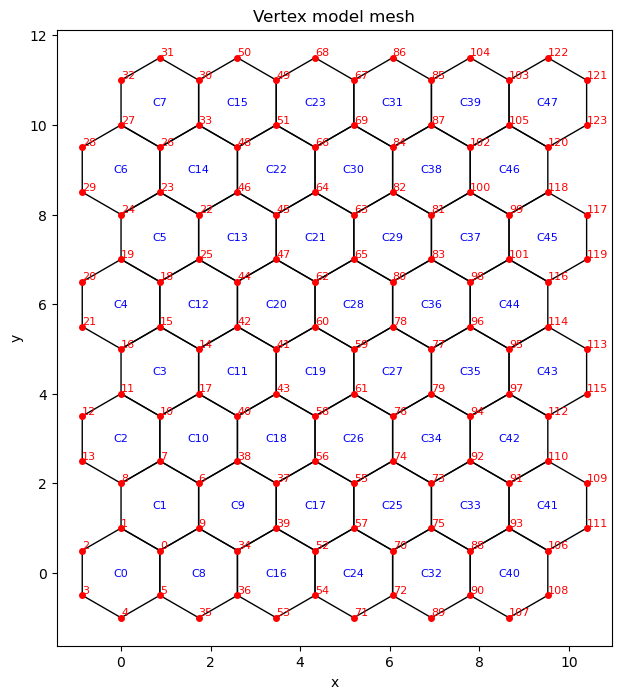

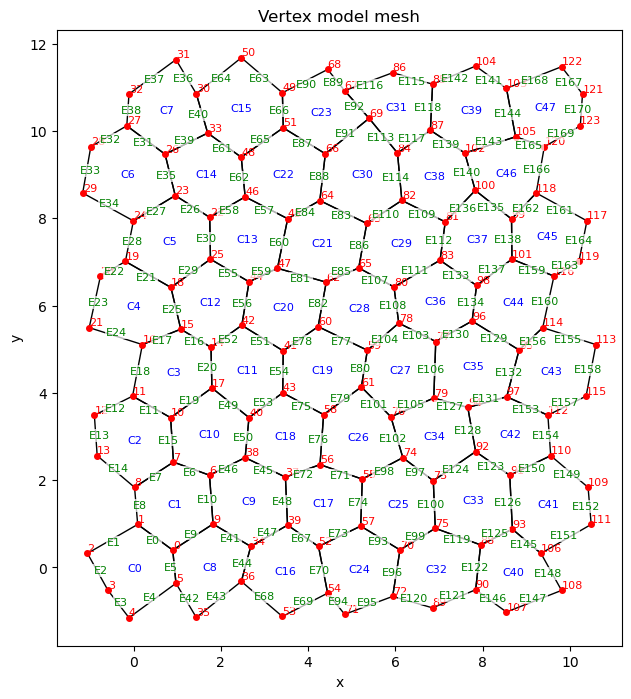

0


 (1)TestRemoval of v2 from A would cause intersection, removing v1
Removed from Cell A vertex id= 17  Removed from Cell B vertex id= 14
Step 4 success Adding vertices at 2 5
10
20
30
40
50
60
70
80
90


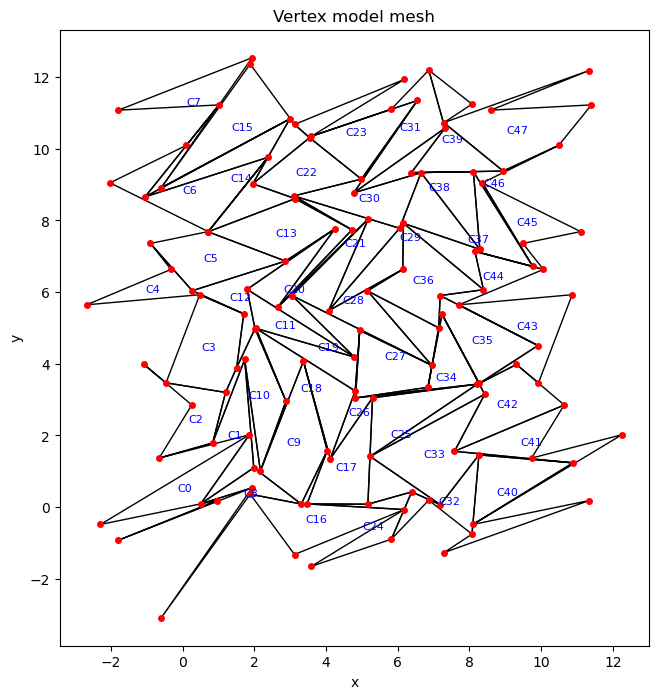

In [14]:
import numpy as np
#Set python random seed to always get the same results...
rng = np.random.default_rng(42)

from source_py_files import topology_v3 as topology
from source_py_files import gradient_descent as gradient_descent_module
tissue_AtMinimum=Tissue()
mesh.generate_hexagonal_sheet(tissue_AtMinimum,Nx,Ny,a,top_bottom_boundary_periodicity=True,side_boundary_periodicity=True)
plotting.plot_mesh(tissue_AtMinimum,show_cell_ids=True,show_vertex_ids=True,show_periodic=False,show_edge_ids=False)
kaValue=1.0;
kpValue=1.0;
LambdaValue=0.0;
noiseSigmaValue=0.001;

noise_sigma=0.1
for vertex in tissue_AtMinimum.vertices:
    vertexid=vertex.id
    xShift= rng.normal(0.0, noise_sigma)
    yShift= rng.normal(0.0, noise_sigma)
    tissue_AtMinimum.move_vertex(vertexid,[xShift,yShift, 0.0])
plotting.plot_mesh(tissue_AtMinimum,show_cell_ids=True,show_vertex_ids=True,show_periodic=False,show_edge_ids=True)

totalT1Transitions=0
tissue_AtMinimum.set_preferred_properties(A0=2.6,P0=6.0)

for i in range(100):    
    gradient_descent_module.gradient_descent_update_positions_with_noise(tissue_AtMinimum,
    nTimesteps=2,ka=kaValue,kp=kpValue,Lambda=LambdaValue,perturb_distance_x=0.05,perturb_distance_y=0.05, friction=0.01,noise_sigma=noiseSigmaValue,print_force=False)

    totalT1Transitions=totalT1Transitions+ topology.perform_t1_transitions(tissue_AtMinimum,t1_threshold=0.3,new_edge_length=0.5,max_transitions=None)
    #print("Total t1 transitions = ",totalT1Transitions)
    
    if(i%10==0):
        print(i)

plotting.plot_mesh(tissue_AtMinimum,show_cell_ids=True,show_vertex_ids=False,show_periodic=False,show_edge_ids=False)


# References
<a name = "cite-note-1">[1]</a> Marder, M. (1987) Soap-bubble growth}, Physical Review A.

<a name = "cite-note-2">[2]</a> Tohru Okuzono and Kyozi Kawasaki. (1995) Intermittent flow behavior of random foams: A computer experiment on foam rheology. Physical Review E



# Concluding Remarks

If you've made it this far, you've now completed most of the practical! Other additions we didn't consider include the other Toplogical transitions, which matter when your cell surface is not periodic, and cells can grow to allow for e.g. cell division, or compress to simulate cell death.

A key feature of these systems is that the cell scale properties significantly affect tissue level structures, and how they evolve. Vertex models have been used to generate quantitative evidence where the cells transition from solid like to fluid like, based on for example, relative proportions of cell tension and boundary adherence. These transitions change how the tissues are able to respond to applied mechanical stresses. Such transitions across scales are the focus of lots of current biophysical research.

In this practical we demonstrated one method that is used in many areas of physics, specifically how defining an energertic description of a system lets you make predictions for how it should evolve, and how one can implement this computationally. The trick is often in how to define a biologically meaningful energy, which then lets you start with a purely numerical description. The choice of energy depends strongly on what is considered biologically relevant, which is often informed through experimental procedures. Hopefully it has been informative to demonstrate how such a energtic description can then be applied!
